In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_deprojection_diagram():
    """
    Generates a 3-panel diagram illustrating the deprojection of 3D shells
    into a 2D profile using explicit color mixing symbolism.
    
    Work flow: Outside -> In. Outskirt colors are 'fixed' first.
    """

    # --- Configuration ---
    # Radius of the three 3D layers
    r1, r2, r3 = 1.0, 2.0, 3.0
    
    # Coordinates for center circle overlay in each plot
    center_xy = (r3, r3) # Centered in a box proportional to outermost radius
    plot_dim = r3 * 2.05 # Box size

    # --- Color Palette (Using Red/Yellow/Blue for intuitive mixing symbolism) ---
    # 1. Native/True Colors of the Intrinsic 3D Shells:
    c_true1 = '#EE6677' # Core: Soft Red (Hot)
    c_true2 = '#CCBB44' # Middle: Soft Yellow (Transition)
    c_true3 = '#4477AA' # Outskirts: Soft Blue (Cool)
    
    # 2. Symbolic Mixed Colors seen in observation (simulating overlaps):
    c_mix23 = '#228833' # Middle+Outskirts (Yellow+Blue = Green)
    c_mix_all = '#666666' # Core+Mid+Out (Red+Yellow+Blue = Muddy Brown/Grey)

    # --- Set up Subplots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.subplots_adjust(wspace=0.1)

    titles = [
        "Panel 1: Raw Observation\n(All layers mixed over the core)",
        "Panel 2: Deprojection Step 1\n(Subtract Outskirts layer 3)",
        "Panel 3: Final Deprojected Profile\n(True intrinsic colors recovered)"
    ]

    # --- Global styling for patches (removing outline for 'mixing' look) ---
    patch_kw = {'edgecolor': 'none', 'linewidth': 0}

    # --- Loop through panels and draw ---
    for i in range(3):
        ax = axes[i]
        
        # Draw background color (optional, help define edge)
        # ax.add_patch(patches.Rectangle((0, 0), plot_dim, plot_dim, facecolor='fuchsia', alpha=0.1))

        # We draw from biggest radius inward so newer layers overlay older ones.
        
        # 1. OUTSKIRTS LAYER (Shell 3) - Becomes true Blue from the very start
        ax.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, **patch_kw))

        # 2. MIDDLE LAYER (Shell 2) - In Panel 1 is Green, then becomes Yellow
        if i == 0:
            color2 = c_mix23  # Still mixed with Outskirts
        else:
            color2 = c_true2  # Fixed/True Yellow
        ax.add_patch(patches.Circle(center_xy, r2, facecolor=color2, **patch_kw))

        # 3. CORE LAYER (Shell 1) - Mixed Muddy -> Transition -> True Red
        if i == 0:
            color1 = c_mix_all # Raw Muddy Mix (R+Y+B)
        elif i == 1:
            color1 = c_mix_all # *CONCEPT CHECK:* While layer 3 is gone, 
                               # Layer 1 core is STILL mixed with Layer 2 inside.
                               # We represent this intermediate muddiness by keeping it
                               # muddy brown, or perhaps shifting to magenta/blue if preferred.
                               # To strictly follow outside-in logic, we haven't fixed layer 1 yet.
        else:
            color1 = c_true1 # Finally True Red
        ax.add_patch(patches.Circle(center_xy, r1, facecolor=color1, **patch_kw))

        # --- Subplot Styling ---
        ax.set_title(titles[i], fontsize=14, pad=15)
        ax.set_xlim(0, plot_dim)
        ax.set_ylim(0, plot_dim)
        ax.set_aspect('equal') # Circles must be round
        ax.axis('off')         # Remove axes/spines/ticks

    # --- Add Legend ---
    # Create proxy artists for legend
    l_c = patches.Patch(color=c_true1, label='True Core (Shell 1)')
    l_m = patches.Patch(color=c_true2, label='True Middle (Shell 2)')
    l_o = patches.Patch(color=c_true3, label='True Outskirts (Shell 3)')
    l_mix23 = patches.Patch(color=c_mix23, label='Mixed Mid+Out Obs')
    l_mix_all = patches.Patch(color=c_mix_all, label='Muddy Raw Core Obs')

    fig.legend(handles=[l_o, l_m, l_c, l_mix23, l_mix_all], 
               loc='lower center', ncol=3, fontsize=12, frameon=False, 
               bbox_to_anchor=(0.5, 0.05))

    # plt.tight_layout() # Usually helps, but subplots_adjust manually handled space
    plt.show()

generate_deprojection_diagram()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def generate_harmonious_deprojection():
    """
    Generates a 3-panel diagram illustrating the deprojection of 3D shells
    into a 1D profile using harmonious, perceptually derived intermediate mixes.
    
    Workflow: Outside -> In. Outskirt colors are 'fixed' first.
    Includes a 1D profile representation for each step.
    """

    # --- Configuration ---
    r1, r2, r3 = 1.0, 2.0, 3.0
    radii = [r1, r2, r3]
    
    center_xy = (r3, r3) 
    plot_dim = r3 * 2.05 

    # --- Harmonious Palette (Sunset Orchid) ---
    # 1. True Colors of the Intrinsic 3D Shells (Base Data)
    c_true1 = '#e08a3f' # Core: Sunset Orange (Warmest)
    c_true2 = '#b14ec7' # Middle: Royal Magenta (Transition)
    c_true3 = '#2a115c' # Outskirts: Midnight Purple (Coolest)
    
    # 2. Derived Intermediate Harmonious Mixes (Symbolizing Process Steps)
    c_obs_core = '#8a4ec7' # Raw Core Obs (Mix 1+2+3): Dusty Orchid
    c_dep_core = '#c7624e' # Partially Deproj Core (Mix 1+2): Deep Coral
    c_mix_23   = '#562994' # Middle Obs (Mix 2+3): Amethyst Violet

    # --- Set up Subplots with Constrained Layout ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), layout="constrained")

    panel_titles = [
        "Panel 1: Raw Observation\n(All layers mixed in core)",
        "Panel 2: Deprojection Step 1\n(Subtract Outskirts Shell 3)",
        "Panel 3: Final Deprojected Profile\n(True intrinsic colors recovered)"
    ]

    row_titles = ["2D Projected Data", "1D Interpreted Profile (Radial Binning)"]

    # Global styling for patches and lines
    patch_kw = {'edgecolor': 'none', 'linewidth': 0}
    
    # FIX: Corrected 'edgecolor' to 'markeredgecolor' for Line2D compatibility
    line_kw = {
        'linestyle': '-', 
        'linewidth': 4, 
        'marker': 'o', 
        'markersize': 12, 
        'markeredgecolor': 'white', 
        'markeredgewidth': 2
    }

    # --- MAIN VISUALIZATION LOOP ---
    for i in range(3):
        
        # --- ROW 1: DRAW OVERLAPPING CIRCLES ---
        ax_2d = axes[0, i]
        ax_2d.set_title(panel_titles[i], fontsize=15, pad=15)
        
        # 1. OUTSKIRTS LAYER (Shell 3)
        ax_2d.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, **patch_kw))

        # 2. MIDDLE LAYER (Shell 2)
        if i == 0:
            color2 = c_mix_23  
        else:
            color2 = c_true2  
        ax_2d.add_patch(patches.Circle(center_xy, r2, facecolor=color2, **patch_kw))

        # 3. CORE LAYER (Shell 1)
        if i == 0:
            color1 = c_obs_core 
        elif i == 1:
            color1 = c_dep_core 
        else:
            color1 = c_true1 
        ax_2d.add_patch(patches.Circle(center_xy, r1, facecolor=color1, **patch_kw))

        # Subplot Styling (2D)
        ax_2d.set_xlim(0, plot_dim)
        ax_2d.set_ylim(0, plot_dim)
        ax_2d.set_aspect('equal')
        ax_2d.axis('off')

        # --- ROW 2: DRAW 1D RADIAL PROFILE ---
        ax_1d = axes[1, i]
        
        if i == 0: 
            values = np.array([4.0, 2.5, 1.0]) 
            v_obs_core, v_mix_23, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_obs_core, c=c_obs_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_mix_23,   c=c_mix_23,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,    c=c_true3,    s=150, zorder=10, **patch_kw)

        elif i == 1: 
            v3_contrib = 0.8 
            values = np.array([4.0 - v3_contrib, 2.5 - v3_contrib, 1.0]) 
            v_dep_core, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_dep_core, c=c_dep_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2,   c=c_true2,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,   c=c_true3,   s=150, zorder=10, **patch_kw)

        else: 
            v3_contrib = 0.8
            v2_contrib = 1.2 
            values = np.array([4.0 - v3_contrib - v2_contrib, 2.5 - v3_contrib, 1.0]) 
            v_true1, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_true1, c=c_true1, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2, c=c_true2, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3, c=c_true3, s=150, zorder=10, **patch_kw)

        # Subplot Styling (1D)
        ax_1d.set_xticks(radii)
        ax_1d.set_xticklabels([f"r = {r}" for r in radii], fontsize=11)
        ax_1d.set_ylabel("Intensity Profile Value", fontsize=11)
        ax_1d.set_ylim(0.5, 4.5) 
        
        ax_1d.grid(axis='y', color='#999999', alpha=0.2, linewidth=0.5, zorder=-1)
        ax_1d.tick_params(axis='both', which='major', labelsize=10, color='#999999')
        ax_1d.spines['top'].set_visible(False)
        ax_1d.spines['right'].set_visible(False)
        ax_1d.spines['bottom'].set_color('#bbbbbb')
        ax_1d.spines['left'].set_color('#bbbbbb')

    # Global Row Labels via Figure Text
    fig.text(0.5, 0.96, row_titles[0], ha='center', fontsize=18, fontweight='bold', color=c_true3)
    fig.text(0.5, 0.46, row_titles[1], ha='center', fontsize=18, fontweight='bold', color='#555555')

    # --- Harmonious Legend Setup ---
    handles = [
        patches.Patch(color=c_true3,   label='True Outskirts (Shell 3, Fixed)'),
        patches.Patch(color=c_true2,   label='True Middle (Shell 2, Solved)'),
        patches.Patch(color=c_true1,   label='True Core (Shell 1, Solved)'),
        patches.Patch(color=c_mix_23,   label='Observed Middle Region (Mix 2+3)'),
        patches.Patch(color=c_dep_core,  label='Partially Deproj Core (Mix 1+2)'),
        patches.Patch(color=c_obs_core,  label='Raw Observed Core (Mix 1+2+3)')
    ]

    fig.legend(handles=handles, 
               loc='lower center', ncol=3, fontsize=11, frameon=False, 
               bbox_to_anchor=(0.5, -0.02), labelcolor='#444444')

    plt.show()

generate_harmonious_deprojection()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def generate_harmonious_deprojection():
    """
    Generates a 3-panel diagram illustrating the deprojection of 3D shells
    into a 1D profile using harmonious, perceptually derived intermediate mixes.
    
    Workflow: Outside -> In. Outskirt colors are 'fixed' first.
    Includes a 1D profile representation for each step.
    """

    # --- Configuration ---
    r1, r2, r3 = 1.0, 2.0, 3.0
    radii = [r1, r2, r3]
    
    center_xy = (r3, r3) 
    plot_dim = r3 * 2.05 

    # --- Harmonious Palette (Sunset Orchid) ---
    # 1. True Colors of the Intrinsic 3D Shells (Base Data)
    c_true1 = '#eb662d' 
    c_true2 = '#d9ab2b' 
    c_true3 = '#588a3e' 
    
    # 2. Derived Intermediate Harmonious Mixes (Symbolizing Process Steps)
    c_obs_core = '#a7bd60' 
    c_dep_core = '#e39140' 
    c_mix_23   = '#81a157' 

    # --- Set up Subplots with Constrained Layout ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), layout="constrained")

    panel_titles = [
        "Panel 1: Raw Observation\n(All layers mixed in core)",
        "Panel 2: Deprojection Step 1\n(Subtract Outskirts Shell 3)",
        "Panel 3: Final Deprojected Profile\n(True intrinsic colors recovered)"
    ]

    row_titles = ["2D Projected Data", "1D Interpreted Profile (Radial Binning)"]

    # Global styling for patches and lines
    patch_kw = {'edgecolor': 'none', 'linewidth': 0}
    
    # FIX: Corrected 'edgecolor' to 'markeredgecolor' for Line2D compatibility
    line_kw = {
        'linestyle': '-', 
        'linewidth': 4, 
        'marker': 'o', 
        'markersize': 12, 
        'markeredgecolor': 'white', 
        'markeredgewidth': 2
    }

    # --- MAIN VISUALIZATION LOOP ---
    for i in range(3):
        
        # --- ROW 1: DRAW OVERLAPPING CIRCLES ---
        ax_2d = axes[0, i]
        ax_2d.set_title(panel_titles[i], fontsize=15, pad=15)
        
        # 1. OUTSKIRTS LAYER (Shell 3)
        ax_2d.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, **patch_kw))

        # 2. MIDDLE LAYER (Shell 2)
        if i == 0:
            color2 = c_mix_23  
        else:
            color2 = c_true2  
        ax_2d.add_patch(patches.Circle(center_xy, r2, facecolor=color2, **patch_kw))

        # 3. CORE LAYER (Shell 1)
        if i == 0:
            color1 = c_obs_core 
        elif i == 1:
            color1 = c_dep_core 
        else:
            color1 = c_true1 
        ax_2d.add_patch(patches.Circle(center_xy, r1, facecolor=color1, **patch_kw))

        # Subplot Styling (2D)
        ax_2d.set_xlim(0, plot_dim)
        ax_2d.set_ylim(0, plot_dim)
        ax_2d.set_aspect('equal')
        ax_2d.axis('off')

        # --- ROW 2: DRAW 1D RADIAL PROFILE ---
        ax_1d = axes[1, i]
        
        if i == 0: 
            values = np.array([4.0, 2.5, 1.0]) 
            v_obs_core, v_mix_23, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_obs_core, c=c_obs_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_mix_23,   c=c_mix_23,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,    c=c_true3,    s=150, zorder=10, **patch_kw)

        elif i == 1: 
            v3_contrib = 0.8 
            values = np.array([4.0 - v3_contrib, 2.5 - v3_contrib, 1.0]) 
            v_dep_core, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_dep_core, c=c_dep_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2,   c=c_true2,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,   c=c_true3,   s=150, zorder=10, **patch_kw)

        else: 
            v3_contrib = 0.8
            v2_contrib = 1.2 
            values = np.array([4.0 - v3_contrib - v2_contrib, 2.5 - v3_contrib, 1.0]) 
            v_true1, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_true1, c=c_true1, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2, c=c_true2, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3, c=c_true3, s=150, zorder=10, **patch_kw)

        # Subplot Styling (1D)
        ax_1d.set_xticks(radii)
        ax_1d.set_xticklabels([f"r = {r}" for r in radii], fontsize=11)
        ax_1d.set_ylabel("Intensity Profile Value", fontsize=11)
        ax_1d.set_ylim(0.5, 4.5) 
        
        ax_1d.grid(axis='y', color='#999999', alpha=0.2, linewidth=0.5, zorder=-1)
        ax_1d.tick_params(axis='both', which='major', labelsize=10, color='#999999')
        ax_1d.spines['top'].set_visible(False)
        ax_1d.spines['right'].set_visible(False)
        ax_1d.spines['bottom'].set_color('#bbbbbb')
        ax_1d.spines['left'].set_color('#bbbbbb')

    # Global Row Labels via Figure Text
    fig.text(0.5, 0.96, row_titles[0], ha='center', fontsize=18, fontweight='bold', color=c_true3)
    fig.text(0.5, 0.46, row_titles[1], ha='center', fontsize=18, fontweight='bold', color='#555555')

    # --- Harmonious Legend Setup ---
    handles = [
        patches.Patch(color=c_true3,   label='True Outskirts (Shell 3, Fixed)'),
        patches.Patch(color=c_true2,   label='True Middle (Shell 2, Solved)'),
        patches.Patch(color=c_true1,   label='True Core (Shell 1, Solved)'),
        patches.Patch(color=c_mix_23,   label='Observed Middle Region (Mix 2+3)'),
        patches.Patch(color=c_dep_core,  label='Partially Deproj Core (Mix 1+2)'),
        patches.Patch(color=c_obs_core,  label='Raw Observed Core (Mix 1+2+3)')
    ]

    fig.legend(handles=handles, 
               loc='lower center', ncol=3, fontsize=11, frameon=False, 
               bbox_to_anchor=(0.5, -0.02), labelcolor='#444444')

    plt.show()

generate_harmonious_deprojection()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def generate_harmonious_deprojection():
    """
    Generates a 3-panel diagram illustrating the deprojection of 3D shells
    into a 1D profile using harmonious, perceptually derived intermediate mixes.
    
    Workflow: Outside -> In. Outskirt colors are 'fixed' first.
    Includes a 1D profile representation for each step.
    """

    # --- Configuration ---
    r1, r2, r3 = 1.0, 2.0, 3.0
    radii = [r1, r2, r3]
    
    center_xy = (r3, r3) 
    plot_dim = r3 * 2.05 

    # --- TRUE INTERPOLATED PALETTE ---
    # 1. Base Colors requested
    c_true1 = '#b22222' # Core: Firebrick
    c_true2 = '#daa520' # Middle: Goldenrod
    c_true3 = '#6b8e23' # Outskirts: Olivedrab
    
    # 2. Mathematically Interpolated Mixes
    c_obs_core = '#a87222' # Raw Observed Core (1/3 Firebrick, 1/3 Goldenrod, 1/3 Olivedrab)
    c_dep_core = '#c66421' # Partially Deproj Core (1/2 Firebrick, 1/2 Goldenrod)
    c_mix_23   = '#a49a22' # Observed Middle Region (1/2 Goldenrod, 1/2 Olivedrab)

    # --- Set up Subplots with Constrained Layout ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), layout="constrained")

    panel_titles = [
        "Panel 1: Raw Observation\n(All layers mixed in core)",
        "Panel 2: Deprojection Step 1\n(Subtract Outskirts Shell 3)",
        "Panel 3: Final Deprojected Profile\n(True intrinsic colors recovered)"
    ]

    row_titles = ["2D Projected Data", "1D Interpreted Profile (Radial Binning)"]

    # Global styling for patches and lines
    patch_kw = {'edgecolor': 'none', 'linewidth': 0}
    
    # FIX: Corrected 'edgecolor' to 'markeredgecolor' for Line2D compatibility
    line_kw = {
        'linestyle': '-', 
        'linewidth': 4, 
        'marker': 'o', 
        'markersize': 12, 
        'markeredgecolor': 'white', 
        'markeredgewidth': 2
    }

    # --- MAIN VISUALIZATION LOOP ---
    for i in range(3):
        
        # --- ROW 1: DRAW OVERLAPPING CIRCLES ---
        ax_2d = axes[0, i]
        ax_2d.set_title(panel_titles[i], fontsize=15, pad=15)
        
        # 1. OUTSKIRTS LAYER (Shell 3)
        ax_2d.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, **patch_kw))

        # 2. MIDDLE LAYER (Shell 2)
        if i == 0:
            color2 = c_mix_23  
        else:
            color2 = c_true2  
        ax_2d.add_patch(patches.Circle(center_xy, r2, facecolor=color2, **patch_kw))

        # 3. CORE LAYER (Shell 1)
        if i == 0:
            color1 = c_obs_core 
        elif i == 1:
            color1 = c_dep_core 
        else:
            color1 = c_true1 
        ax_2d.add_patch(patches.Circle(center_xy, r1, facecolor=color1, **patch_kw))

        # Subplot Styling (2D)
        ax_2d.set_xlim(0, plot_dim)
        ax_2d.set_ylim(0, plot_dim)
        ax_2d.set_aspect('equal')
        ax_2d.axis('off')

        # --- ROW 2: DRAW 1D RADIAL PROFILE ---
        ax_1d = axes[1, i]
        
        if i == 0: 
            values = np.array([4.0, 2.5, 1.0]) 
            v_obs_core, v_mix_23, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_obs_core, c=c_obs_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_mix_23,   c=c_mix_23,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,    c=c_true3,    s=150, zorder=10, **patch_kw)

        elif i == 1: 
            v3_contrib = 0.8 
            values = np.array([4.0 - v3_contrib, 2.5 - v3_contrib, 1.0]) 
            v_dep_core, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_dep_core, c=c_dep_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2,   c=c_true2,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,   c=c_true3,   s=150, zorder=10, **patch_kw)

        else: 
            v3_contrib = 0.8
            v2_contrib = 1.2 
            values = np.array([4.0 - v3_contrib - v2_contrib, 2.5 - v3_contrib, 1.0]) 
            v_true1, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_true1, c=c_true1, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2, c=c_true2, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3, c=c_true3, s=150, zorder=10, **patch_kw)

        # Subplot Styling (1D)
        ax_1d.set_xticks(radii)
        ax_1d.set_xticklabels([f"r = {r}" for r in radii], fontsize=11)
        ax_1d.set_ylabel("Intensity Profile Value", fontsize=11)
        ax_1d.set_ylim(0.5, 4.5) 
        
        ax_1d.grid(axis='y', color='#999999', alpha=0.2, linewidth=0.5, zorder=-1)
        ax_1d.tick_params(axis='both', which='major', labelsize=10, color='#999999')
        ax_1d.spines['top'].set_visible(False)
        ax_1d.spines['right'].set_visible(False)
        ax_1d.spines['bottom'].set_color('#bbbbbb')
        ax_1d.spines['left'].set_color('#bbbbbb')

    # Global Row Labels via Figure Text
    fig.text(0.5, 0.96, row_titles[0], ha='center', fontsize=18, fontweight='bold', color=c_true3)
    fig.text(0.5, 0.46, row_titles[1], ha='center', fontsize=18, fontweight='bold', color='#555555')

    # --- Harmonious Legend Setup ---
    handles = [
        patches.Patch(color=c_true3,   label='True Outskirts (Shell 3, Fixed)'),
        patches.Patch(color=c_true2,   label='True Middle (Shell 2, Solved)'),
        patches.Patch(color=c_true1,   label='True Core (Shell 1, Solved)'),
        patches.Patch(color=c_mix_23,   label='Observed Middle Region (Mix 2+3)'),
        patches.Patch(color=c_dep_core,  label='Partially Deproj Core (Mix 1+2)'),
        patches.Patch(color=c_obs_core,  label='Raw Observed Core (Mix 1+2+3)')
    ]

    fig.legend(handles=handles, 
               loc='lower center', ncol=3, fontsize=11, frameon=False, 
               bbox_to_anchor=(0.5, -0.02), labelcolor='#444444')

    plt.show()

generate_harmonious_deprojection()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def generate_harmonious_deprojection():
    """
    Generates a 3-panel diagram illustrating the deprojection of 3D shells
    into a 1D profile using harmonious, perceptually derived intermediate mixes.
    
    Workflow: Outside -> In. Outskirt colors are 'fixed' first.
    Includes a 1D profile representation for each step.
    """

    # --- Configuration ---
    r1, r2, r3 = 1.0, 2.0, 3.0
    radii = [r1, r2, r3]
    
    center_xy = (r3, r3) 
    plot_dim = r3 * 2.05 
    
    # NEW: Control how thin the colored rings are
    ring_thickness = 0.9

    # --- TRUE INTERPOLATED PALETTE ---
    # 1. Base Colors requested
    c_true1 = '#b22222' # Core: Firebrick
    c_true2 = '#daa520' # Middle: Goldenrod
    c_true3 = '#6b8e23' # Outskirts: Olivedrab
    
    # 2. Mathematically Interpolated Mixes
    c_obs_core = '#a87222' # Raw Observed Core (1/3 Firebrick, 1/3 Goldenrod, 1/3 Olivedrab)
    c_dep_core = '#c66421' # Partially Deproj Core (1/2 Firebrick, 1/2 Goldenrod)
    c_mix_23   = '#a49a22' # Observed Middle Region (1/2 Goldenrod, 1/2 Olivedrab)

    # --- Set up Subplots with Constrained Layout ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), layout="constrained")

    panel_titles = [
        "Panel 1: Raw Observation\n(All layers mixed in core)",
        "Panel 2: Deprojection Step 1\n(Subtract Outskirts Shell 3)",
        "Panel 3: Final Deprojected Profile\n(True intrinsic colors recovered)"
    ]

    row_titles = ["2D Projected Data", "1D Interpreted Profile (Radial Binning)"]

    # Global styling for patches and lines
    patch_kw = {'edgecolor': 'none', 'linewidth': 0}
    
    line_kw = {
        'linestyle': '-', 
        'linewidth': 4, 
        'marker': 'o', 
        'markersize': 12, 
        'markeredgecolor': 'white', 
        'markeredgewidth': 2
    }

    # --- MAIN VISUALIZATION LOOP ---
    for i in range(3):
        
        # --- ROW 1: DRAW OVERLAPPING CIRCLES ---
        ax_2d = axes[0, i]
        ax_2d.set_title(panel_titles[i], fontsize=15, pad=15)
        
        # 1. OUTSKIRTS LAYER (Shell 3)
        ax_2d.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, **patch_kw))
        # Mask the inside with white to make it a thin ring
        ax_2d.add_patch(patches.Circle(center_xy, r3 - ring_thickness, facecolor='white', **patch_kw))

        # 2. MIDDLE LAYER (Shell 2)
        if i == 0:
            color2 = c_mix_23  
        else:
            color2 = c_true2  
        ax_2d.add_patch(patches.Circle(center_xy, r2, facecolor=color2, **patch_kw))
        # Mask the inside with white
        ax_2d.add_patch(patches.Circle(center_xy, r2 - ring_thickness, facecolor='white', **patch_kw))

        # 3. CORE LAYER (Shell 1)
        if i == 0:
            color1 = c_obs_core 
        elif i == 1:
            color1 = c_dep_core 
        else:
            color1 = c_true1 
        ax_2d.add_patch(patches.Circle(center_xy, r1, facecolor=color1, **patch_kw))
        # Mask the inside with white to turn the central core into a matching ring structure
        ax_2d.add_patch(patches.Circle(center_xy, r1 - ring_thickness, facecolor='white', **patch_kw))

        # Subplot Styling (2D)
        ax_2d.set_xlim(0, plot_dim)
        ax_2d.set_ylim(0, plot_dim)
        ax_2d.set_aspect('equal')
        ax_2d.axis('off')

        # --- ROW 2: DRAW 1D RADIAL PROFILE ---
        ax_1d = axes[1, i]
        
        if i == 0: 
            values = np.array([4.0, 2.5, 1.0]) 
            v_obs_core, v_mix_23, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_obs_core, c=c_obs_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_mix_23,   c=c_mix_23,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,    c=c_true3,    s=150, zorder=10, **patch_kw)

        elif i == 1: 
            v3_contrib = 0.8 
            values = np.array([4.0 - v3_contrib, 2.5 - v3_contrib, 1.0]) 
            v_dep_core, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_dep_core, c=c_dep_core, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2,   c=c_true2,   s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3,   c=c_true3,   s=150, zorder=10, **patch_kw)

        else: 
            v3_contrib = 0.8
            v2_contrib = 1.2 
            values = np.array([4.0 - v3_contrib - v2_contrib, 2.5 - v3_contrib, 1.0]) 
            v_true1, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='#666666', **line_kw)
            
            ax_1d.scatter(r1, v_true1, c=c_true1, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r2, v_true2, c=c_true2, s=150, zorder=10, **patch_kw)
            ax_1d.scatter(r3, v_true3, c=c_true3, s=150, zorder=10, **patch_kw)

        # Subplot Styling (1D)
        ax_1d.set_xticks(radii)
        ax_1d.set_xticklabels([f"r = {r}" for r in radii], fontsize=11)
        ax_1d.set_ylabel("Intensity Profile Value", fontsize=11)
        ax_1d.set_ylim(0.5, 4.5) 
        
        ax_1d.grid(axis='y', color='#999999', alpha=0.2, linewidth=0.5, zorder=-1)
        ax_1d.tick_params(axis='both', which='major', labelsize=10, color='#999999')
        ax_1d.spines['top'].set_visible(False)
        ax_1d.spines['right'].set_visible(False)
        ax_1d.spines['bottom'].set_color('#bbbbbb')
        ax_1d.spines['left'].set_color('#bbbbbb')

    # Global Row Labels via Figure Text
    fig.text(0.5, 0.96, row_titles[0], ha='center', fontsize=18, fontweight='bold', color='#444444')
    fig.text(0.5, 0.46, row_titles[1], ha='center', fontsize=18, fontweight='bold', color='#555555')

    # --- Harmonious Legend Setup ---
    handles = [
        patches.Patch(color=c_true3,   label='True Outskirts (Shell 3, Fixed)'),
        patches.Patch(color=c_true2,   label='True Middle (Shell 2, Solved)'),
        patches.Patch(color=c_true1,   label='True Core (Shell 1, Solved)'),
        patches.Patch(color=c_mix_23,   label='Observed Middle Region (Mix 2+3)'),
        patches.Patch(color=c_dep_core,  label='Partially Deproj Core (Mix 1+2)'),
        patches.Patch(color=c_obs_core,  label='Raw Observed Core (Mix 1+2+3)')
    ]

    fig.legend(handles=handles, 
               loc='lower center', ncol=3, fontsize=11, frameon=False, 
               bbox_to_anchor=(0.5, -0.02), labelcolor='#444444')

    plt.show()

generate_harmonious_deprojection()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def generate_lightweight_deprojection():
    """
    Generates a 3-panel diagram illustrating the deprojection of 3D shells
    using a lightweight, semi-transparent 'glass layer' aesthetic.
    """

    # --- Configuration ---
    r1, r2, r3 = 1.0, 2.0, 3.0
    radii = [r1, r2, r3]
    
    center_xy = (r3, r3) 
    plot_dim = r3 * 2.05 
    
    # NEW: Adjust this to make the circles as light or heavy as you want (0.0 to 1.0)
    alpha_val = 0.75

    # --- TRUE INTERPOLATED PALETTE ---
    c_true1 = '#b22222' # Core: Firebrick
    c_true2 = '#daa520' # Middle: Goldenrod
    c_true3 = '#6b8e23' # Outskirts: Olivedrab
    
    c_obs_core = '#a87222' # Raw Observed Core Mix
    c_dep_core = '#c66421' # Partially Deproj Core Mix
    c_mix_23   = '#a49a22' # Observed Middle Region Mix

    # --- Set up Subplots with Constrained Layout ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), layout="constrained")

    panel_titles = [
        "Panel 1: Raw Observation\n(All layers mixed in core)",
        "Panel 2: Deprojection Step 1\n(Subtract Outskirts Shell 3)",
        "Panel 3: Final Deprojected Profile\n(True intrinsic colors recovered)"
    ]

    row_titles = ["2D Projected Data (Transparent Shells)", "1D Interpreted Profile (Radial Binning)"]

    # Global styling for 1D lines
    line_kw = {
        'linestyle': '-', 
        'linewidth': 3, 
        'marker': 'o', 
        'markersize': 12, 
        'markeredgecolor': 'white', 
        'markeredgewidth': 2
    }

    # --- MAIN VISUALIZATION LOOP ---
    for i in range(3):
        
        # --- ROW 1: DRAW OVERLAPPING TRANSPARENT CIRCLES ---
        ax_2d = axes[0, i]
        ax_2d.set_title(panel_titles[i], fontsize=15, pad=15)
        
        # 1. OUTSKIRTS LAYER (Shell 3)
        ax_2d.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, edgecolor=c_true3, linewidth=1.5, alpha=alpha_val))

        # 2. MIDDLE LAYER (Shell 2)
        if i == 0:
            color2 = c_mix_23  
        else:
            color2 = c_true2  
        ax_2d.add_patch(patches.Circle(center_xy, r2, facecolor=color2, edgecolor=color2, linewidth=1.5, alpha=alpha_val))

        # 3. CORE LAYER (Shell 1)
        if i == 0:
            color1 = c_obs_core 
        elif i == 1:
            color1 = c_dep_core 
        else:
            color1 = c_true1 
        ax_2d.add_patch(patches.Circle(center_xy, r1, facecolor=color1, edgecolor=color1, linewidth=1.5, alpha=alpha_val))

        # Subplot Styling (2D)
        ax_2d.set_xlim(0, plot_dim)
        ax_2d.set_ylim(0, plot_dim)
        ax_2d.set_aspect('equal')
        ax_2d.axis('off')

        # --- ROW 2: DRAW 1D RADIAL PROFILE ---
        # Note: We keep the 1D points completely opaque (no alpha) so they stay easy to read
        ax_1d = axes[1, i]
        
        if i == 0: 
            values = np.array([4.0, 2.5, 1.0]) 
            v_obs_core, v_mix_23, v_true3 = values
            ax_1d.plot(radii, values, color='k', **line_kw)
            
            ax_1d.scatter(r1, v_obs_core, c=c_obs_core, s=150, zorder=10, edgecolor='none')
            ax_1d.scatter(r2, v_mix_23,   c=c_mix_23,   s=150, zorder=10, edgecolor='none')
            ax_1d.scatter(r3, v_true3,    c=c_true3,    s=150, zorder=10, edgecolor='none')

        elif i == 1: 
            v3_contrib = 0.8 
            values = np.array([4.0 - v3_contrib, 2.5 - v3_contrib, 1.0]) 
            v_dep_core, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='k', **line_kw)
            
            ax_1d.scatter(r1, v_dep_core, c=c_dep_core, s=150, zorder=10, edgecolor='none')
            ax_1d.scatter(r2, v_true2,   c=c_true2,   s=150, zorder=10, edgecolor='none')
            ax_1d.scatter(r3, v_true3,   c=c_true3,   s=150, zorder=10, edgecolor='none')

        else: 
            v3_contrib = 0.8
            v2_contrib = 1.2 
            values = np.array([4.0 - v3_contrib - v2_contrib, 2.5 - v3_contrib, 1.0]) 
            v_true1, v_true2, v_true3 = values
            ax_1d.plot(radii, values, color='k', **line_kw)
            
            ax_1d.scatter(r1, v_true1, c=c_true1, s=150, zorder=10, edgecolor='none')
            ax_1d.scatter(r2, v_true2, c=c_true2, s=150, zorder=10, edgecolor='none')
            ax_1d.scatter(r3, v_true3, c=c_true3, s=150, zorder=10, edgecolor='none')

        # Subplot Styling (1D)
        ax_1d.set_xticks(radii)
        ax_1d.set_xticklabels([f"r = {r}" for r in radii], fontsize=11)
        ax_1d.set_ylabel("Intensity Profile Value", fontsize=11)
        ax_1d.set_ylim(0.5, 4.5) 
        
        ax_1d.grid(axis='y', color='#999999', alpha=0.2, linewidth=0.5, zorder=-1)
        ax_1d.tick_params(axis='both', which='major', labelsize=10, color='#999999')
        ax_1d.spines['top'].set_visible(False)
        ax_1d.spines['right'].set_visible(False)
        ax_1d.spines['bottom'].set_color('#bbbbbb')
        ax_1d.spines['left'].set_color('#bbbbbb')

    # Global Row Labels via Figure Text
    fig.text(0.5, 0.96, row_titles[0], ha='center', fontsize=18, fontweight='bold', color='#444444')
    fig.text(0.5, 0.46, row_titles[1], ha='center', fontsize=18, fontweight='bold', color='#555555')

    # --- Harmonious Legend Setup ---
    handles = [
        patches.Patch(color=c_true3,   label='True Outskirts (Shell 3, Fixed)'),
        patches.Patch(color=c_true2,   label='True Middle (Shell 2, Solved)'),
        patches.Patch(color=c_true1,   label='True Core (Shell 1, Solved)'),
        patches.Patch(color=c_mix_23,   label='Observed Middle Region (Mix 2+3)'),
        patches.Patch(color=c_dep_core,  label='Partially Deproj Core (Mix 1+2)'),
        patches.Patch(color=c_obs_core,  label='Raw Observed Core (Mix 1+2+3)')
    ]

    fig.legend(handles=handles, 
               loc='lower center', ncol=3, fontsize=11, frameon=False, 
               bbox_to_anchor=(0.5, -0.02), labelcolor='#444444')

    plt.show()

generate_lightweight_deprojection()

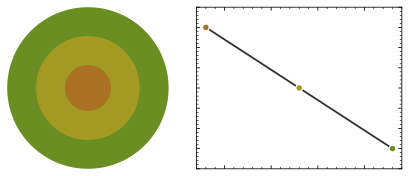

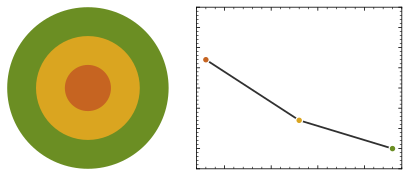

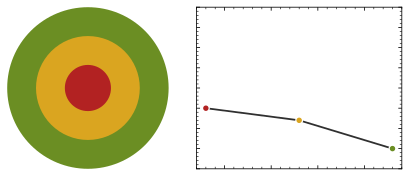

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

r1, r2, r3 = 0.8, 1.8, 2.8
radii = [r1, r2, r3]

center_xy = (r3, r3) 
plot_dim = r3 * 2

c_true1 = '#b22222'
c_true2 = '#daa520'
c_true3 = '#6b8e23'

c_obs_core = '#a87222'
c_dep_core = '#c66421'
c_mix_23 = '#a49a22'

patch_kw = {'edgecolor': 'none', 'linewidth': 0}

line_kw = {
    'linestyle': '-', 
    'linewidth': 1.8, 
    'marker': 'o', 
    'markersize': 6, 
    'markeredgecolor': 'white', 
    'markeredgewidth': 2
}

for i in range(3):
    fig, axes = plt.subplots(1, 2, figsize=(5.88, 2.33), layout="constrained")

    ax_2d = axes[0]
    
    ax_2d.add_patch(patches.Circle(center_xy, r3, facecolor=c_true3, **patch_kw))

    if i == 0:
        color2 = c_mix_23  
    else:
        color2 = c_true2  
    ax_2d.add_patch(patches.Circle(center_xy, r2, facecolor=color2, **patch_kw))

    if i == 0:
        color1 = c_obs_core 
    elif i == 1:
        color1 = c_dep_core 
    else:
        color1 = c_true1 
    ax_2d.add_patch(patches.Circle(center_xy, r1, facecolor=color1, **patch_kw))

    ax_2d.set_xlim(0, plot_dim)
    ax_2d.set_ylim(0, plot_dim)
    ax_2d.set_aspect('equal')
    ax_2d.axis('off')

    ax_1d = axes[1]
    
    if i == 0: 
        values = np.array([4.0, 2.5, 1.0]) 
        v_obs_core, v_mix_23, v_true3 = values
        ax_1d.plot(radii, values, color='#303030', zorder=1, **line_kw)
        
        ax_1d.scatter(r1, v_obs_core, c=c_obs_core, s=30, zorder=10, **patch_kw)
        ax_1d.scatter(r2, v_mix_23,   c=c_mix_23,   s=30, zorder=10, **patch_kw)
        ax_1d.scatter(r3, v_true3,    c=c_true3,    s=30, zorder=10, **patch_kw)

    elif i == 1: 
        v3_contrib = 0.8 
        values = np.array([4.0 - v3_contrib, 2.5 - v3_contrib, 1.0]) 
        v_dep_core, v_true2, v_true3 = values
        ax_1d.plot(radii, values, color='#303030', zorder=1, **line_kw)
        
        ax_1d.scatter(r1, v_dep_core, c=c_dep_core, s=30, zorder=10, **patch_kw)
        ax_1d.scatter(r2, v_true2,   c=c_true2,   s=30, zorder=10, **patch_kw)
        ax_1d.scatter(r3, v_true3,   c=c_true3,   s=30, zorder=10, **patch_kw)

    else: 
        v3_contrib = 0.8
        v2_contrib = 1.2 
        values = np.array([4.0 - v3_contrib - v2_contrib, 2.5 - v3_contrib, 1.0]) 
        v_true1, v_true2, v_true3 = values
        ax_1d.plot(radii, values, color='#303030', zorder=1, **line_kw)
        
        ax_1d.scatter(r1, v_true1, c=c_true1, s=30, zorder=10, **patch_kw)
        ax_1d.scatter(r2, v_true2, c=c_true2, s=30, zorder=10, **patch_kw)
        ax_1d.scatter(r3, v_true3, c=c_true3, s=30, zorder=10, **patch_kw)

    ax_1d.set_xticklabels([])
    ax_1d.set_yticklabels([])
    ax_1d.set_ylim(0.5, 4.5) 

    plt.show()